# **Scatter Plot**


## Overview

In this lab, you will focus on creating and interpreting scatter plots to visualize relationships between variables and trends in the dataset. The provided dataset will be directly loaded into a pandas DataFrame, and various scatter plot-related visualizations will be created to explore developer trends, compensation, and preferences.



## Objectives


In this lab, you will:

- Create and analyze scatter plots to examine relationships between variables.

- Use scatter plots to identify trends and patterns in the dataset.

- Focus on visualizations centered on scatter plots for better data-driven insights.


## Setup: Working with the Database



**Install and import the required libraries**


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

#### Step 1: Load the dataset


In [5]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

df = pd.read_csv(file_path)

In [6]:
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


In [8]:
df = pd.read_csv(file_path)


### Task 1: Exploring Relationships with Scatter Plots



#### 1. Scatter Plot for Age vs. Job Satisfaction



Visualize the relationship between respondents' age (`Age`) and job satisfaction (`JobSatPoints_6`). Use this plot to identify any patterns or trends.




In [9]:
age_map = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29,
    "35-44 years old": 39,
    "45-54 years old": 49,
    "55-64 years old": 59,
    "65 years or older": 70
}

df['Age_numeric'] = df['Age'].map(age_map)

In [10]:
df['JobSatPoints_6'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce')
df_clean = df.dropna(subset=['Age_numeric', 'JobSatPoints_6'])

Text(0, 0.5, 'Job Satisfaction (JobSatPoints_6)')

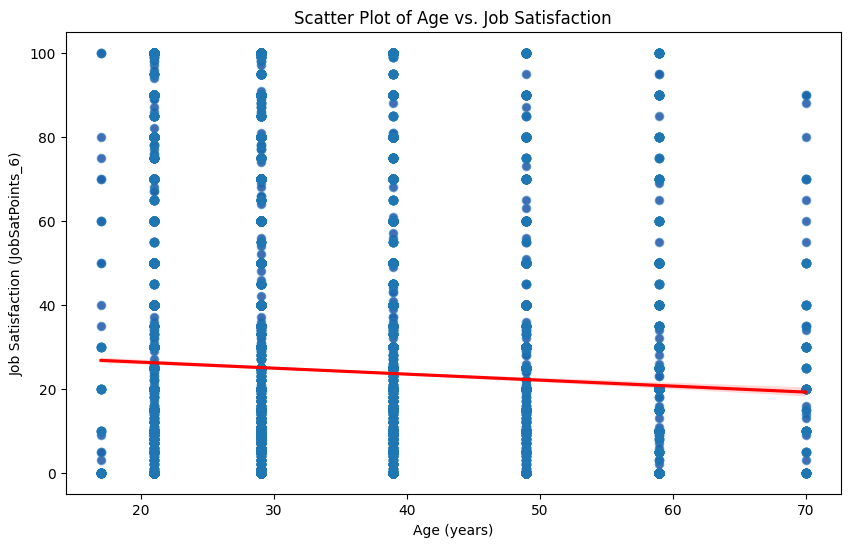

In [13]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="Age_numeric",
    y="JobSatPoints_6",
    data=df_clean,
    alpha=0.6,
    color="darkblue"
)

sns.regplot(
    x="Age_numeric",
    y="JobSatPoints_6",
    data=df_clean,
    scatter_kws={'alpha':0.5},
    line_kws={'color':'red'}
)

plt.title("Scatter Plot of Age vs. Job Satisfaction")
plt.xlabel("Age (years)")
plt.ylabel("Job Satisfaction (JobSatPoints_6)")

#### 2. Scatter Plot for Compensation vs. Job Satisfaction


Explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) using a scatter plot.


In [14]:
# Convert to numeric
df['ConvertedCompYearly'] = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce')
df['JobSatPoints_6'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce')

# Drop rows with missing values
df_clean = df.dropna(subset=['ConvertedCompYearly', 'JobSatPoints_6'])

Text(0, 0.5, 'Job Satisfaction (JobSatPoints_6)')

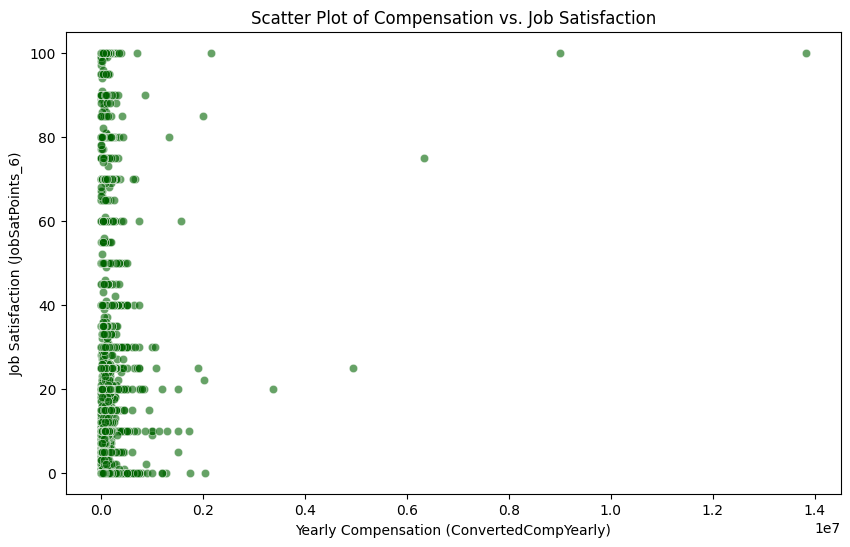

In [15]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="ConvertedCompYearly",
    y="JobSatPoints_6",
    data=df_clean,
    alpha=0.6,
    color="darkgreen"
)

plt.title("Scatter Plot of Compensation vs. Job Satisfaction")
plt.xlabel("Yearly Compensation (ConvertedCompYearly)")
plt.ylabel("Job Satisfaction (JobSatPoints_6)")

### Task 2: Enhancing Scatter Plots


#### 1. Scatter Plot with Trend Line for Age vs. Job Satisfaction



Add a regression line to the scatter plot of Age vs. JobSatPoints_6 to highlight trends in the data.


In [16]:
# Convert Age ranges to numeric midpoints
age_map = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29,
    "35-44 years old": 39,
    "45-54 years old": 49,
    "55-64 years old": 59,
    "65 years or older": 70
}
df['Age_numeric'] = df['Age'].map(age_map)

# Ensure JobSatPoints_6 is numeric
df['JobSatPoints_6'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce')

# Drop missing values
df_clean = df.dropna(subset=['Age_numeric', 'JobSatPoints_6'])

Text(0, 0.5, 'Job Satisfaction (JobSatPoints_6)')

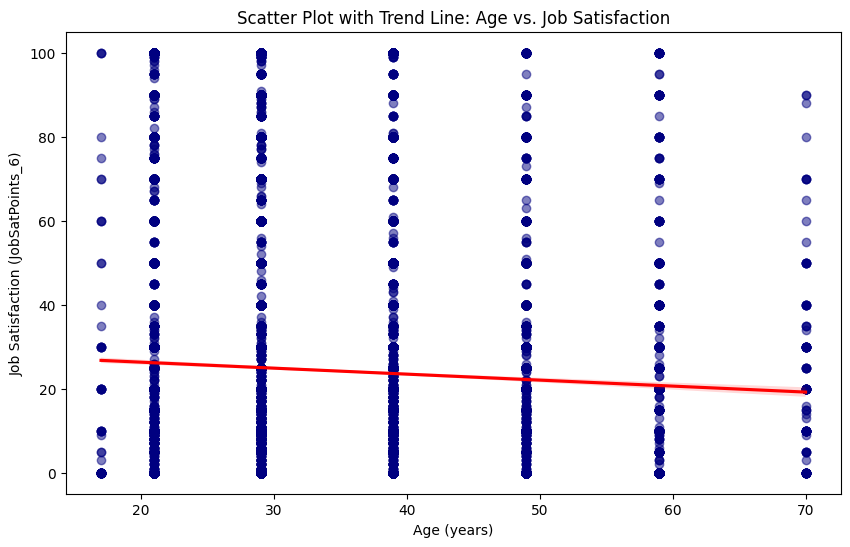

In [17]:
plt.figure(figsize=(10,6))

# Scatter plot with regression line
sns.regplot(
    x="Age_numeric",
    y="JobSatPoints_6",
    data=df_clean,
    scatter_kws={'alpha':0.5, 'color':'navy'},
    line_kws={'color':'red'}
)

plt.title("Scatter Plot with Trend Line: Age vs. Job Satisfaction")
plt.xlabel("Age (years)")
plt.ylabel("Job Satisfaction (JobSatPoints_6)")

#### 2. Scatter Plot for Age vs. Work Experience


Visualize the relationship between Age (`Age`) and Work Experience (`YearsCodePro`) using a scatter plot.


In [18]:
def convert_years(val):
    val = str(val).strip()
    if val.lower().startswith("less than 1"):
        return 0.5
    elif val.lower().startswith("more than 50"):
        return 51
    else:
        try:
            return float(val)
        except:
            return None

df['YearsCodePro_numeric'] = df['YearsCodePro'].apply(convert_years)

In [19]:
df_clean = df.dropna(subset=['Age_numeric', 'YearsCodePro_numeric'])

Text(0, 0.5, 'Work Experience (YearsCodePro)')

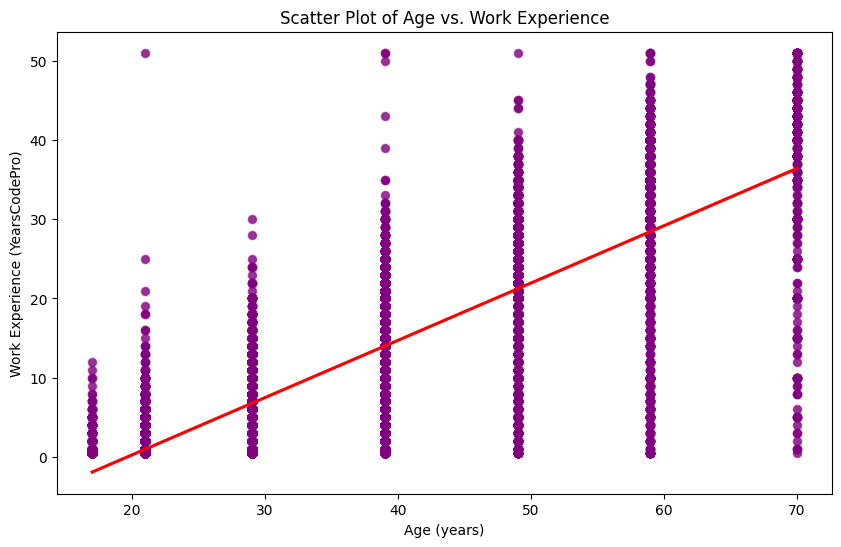

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.scatterplot(
    x="Age_numeric",
    y="YearsCodePro_numeric",
    data=df_clean,
    alpha=0.6,
    color="purple"
)
sns.regplot(
    x="Age_numeric",
    y="YearsCodePro_numeric",
    data=df_clean,
    scatter_kws={'alpha':0.5, 'color':'purple'},
    line_kws={'color':'red'}
)
plt.title("Scatter Plot of Age vs. Work Experience")
plt.xlabel("Age (years)")
plt.ylabel("Work Experience (YearsCodePro)")

### Task 3: Combining Scatter Plots with Additional Features


#### 1. Bubble Plot of Compensation vs. Job Satisfaction with Age as Bubble Size



Create a bubble plot to explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), with bubble size representing age.


In [ ]:
## Write your code hereimport pandas as pd

# Map age ranges to numeric midpoints
age_map = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29,
    "35-44 years old": 39,
    "45-54 years old": 49,
    "55-64 years old": 59,
    "65 years or older": 70
}
df['Age_numeric'] = df['Age'].map(age_map)

# Ensure numeric values
df['ConvertedCompYearly'] = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce')
df['JobSatPoints_6'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce')

# Drop missing values
df_clean = df.dropna(subset=['ConvertedCompYearly', 'JobSatPoints_6', 'Age_numeric'])

In [24]:
# Ensure numeric values
df['ConvertedCompYearly'] = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce')
df['JobSatPoints_6'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce')

# Drop missing values
df_clean = df.dropna(subset=['ConvertedCompYearly', 'JobSatPoints_6', 'Age_numeric'])

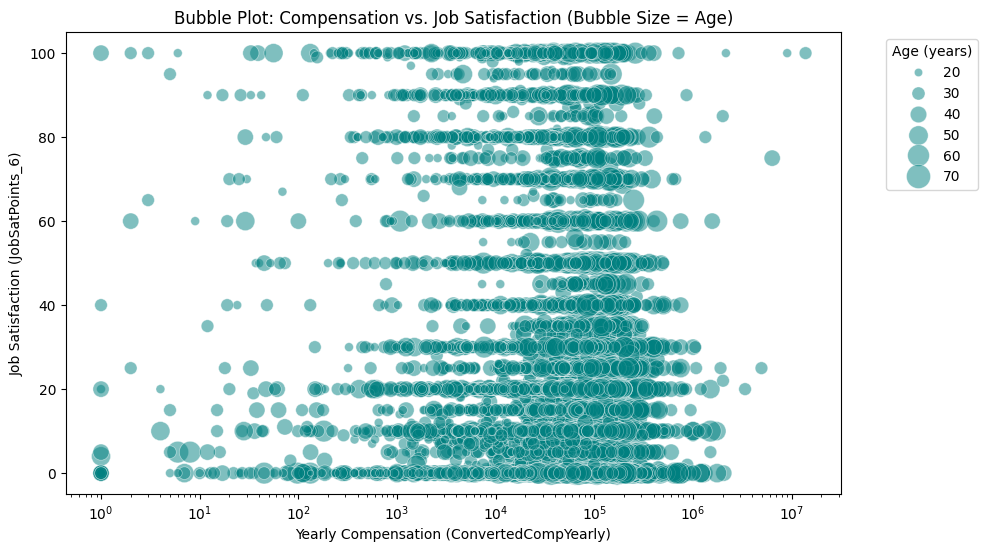

In [26]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="ConvertedCompYearly",
    y="JobSatPoints_6",
    size="Age_numeric",          # bubble size = age
    sizes=(20, 300),             # scale bubble sizes
    alpha=0.5,
    data=df_clean,
    color="teal"
)
plt.xscale("log")
plt.title("Bubble Plot: Compensation vs. Job Satisfaction (Bubble Size = Age)")
plt.xlabel("Yearly Compensation (ConvertedCompYearly)")
plt.ylabel("Job Satisfaction (JobSatPoints_6)")
plt.legend(title="Age (years)", bbox_to_anchor=(1.05, 1), loc='upper left')

#### 2. Scatter Plot for Popular Programming Languages by Job Satisfaction


Visualize the popularity of programming languages (`LanguageHaveWorkedWith`) against job satisfaction using a scatter plot. Use points to represent satisfaction levels for each language.


In [29]:
# Split multiple languages into separate rows
df_lang = df.assign(LanguageHaveWorkedWith=df['LanguageHaveWorkedWith'].str.split(';')).explode('LanguageHaveWorkedWith')
df_lang['LanguageHaveWorkedWith'] = df_lang['LanguageHaveWorkedWith'].str.strip()

df_lang['JobSatPoints_6'] = pd.to_numeric(df_lang['JobSatPoints_6'], errors='coerce')
df_lang = df_lang.dropna(subset=['LanguageHaveWorkedWith', 'JobSatPoints_6'])

In [30]:
lang_summary = df_lang.groupby('LanguageHaveWorkedWith').agg(
    AvgSatisfaction=('JobSatPoints_6', 'mean'),
    RespondentCount=('JobSatPoints_6', 'count')
).reset_index()

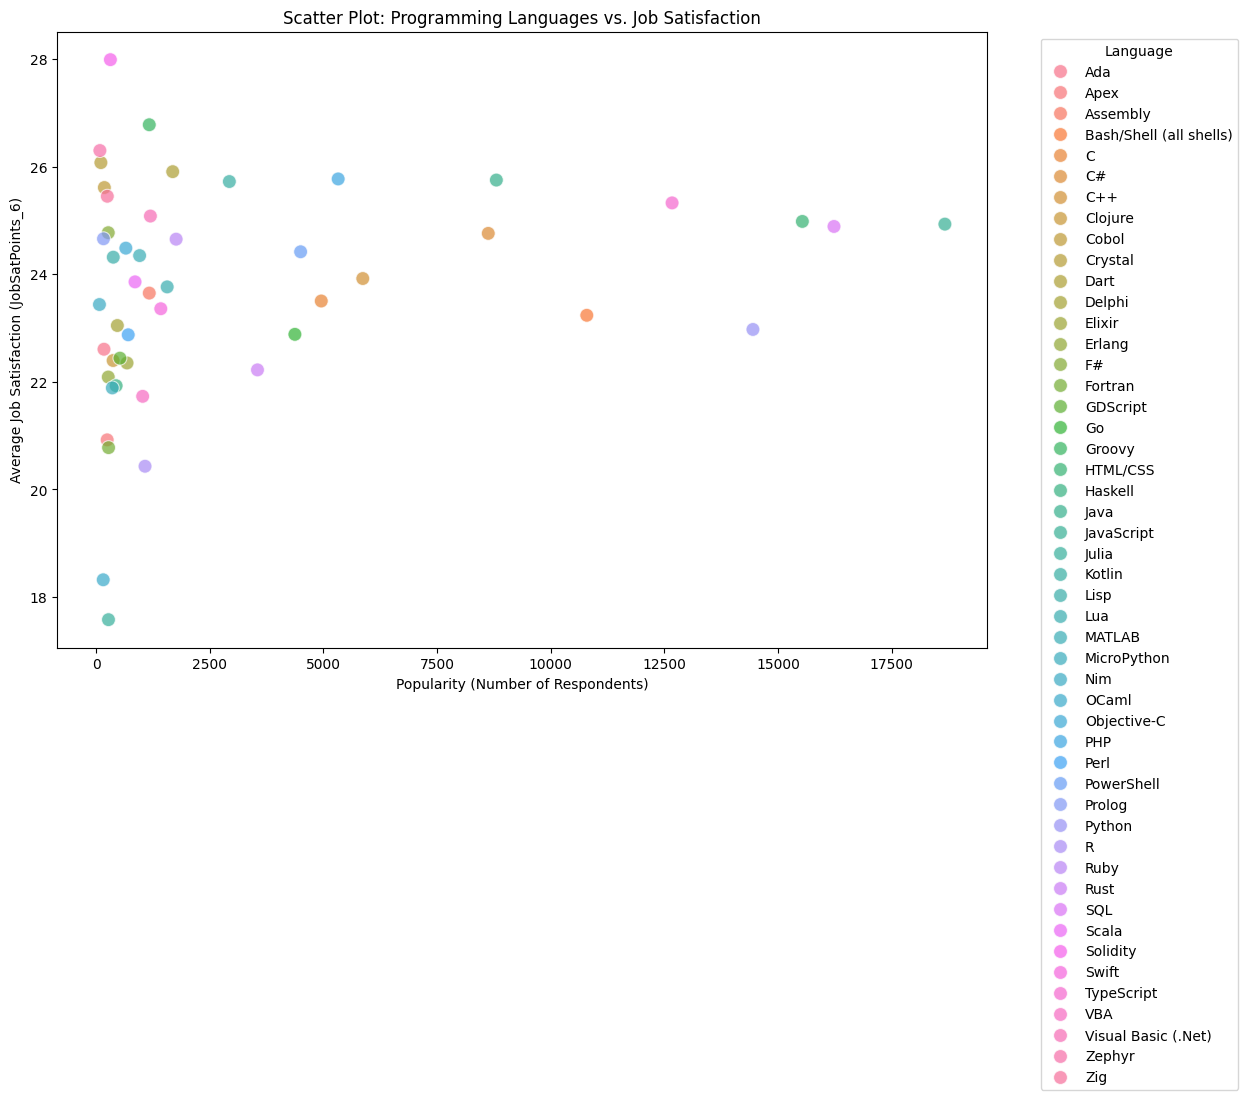

In [33]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    x="RespondentCount",
    y="AvgSatisfaction",
    data=lang_summary,
    hue="LanguageHaveWorkedWith",   # color by language
    alpha=0.7,
    s=100
)

plt.title("Scatter Plot: Programming Languages vs. Job Satisfaction")
plt.xlabel("Popularity (Number of Respondents)")
plt.ylabel("Average Job Satisfaction (JobSatPoints_6)")
plt.legend(title="Language", bbox_to_anchor=(1.05, 1), loc='upper left')

### Task 4: Scatter Plot Comparisons Across Groups


#### 1. Scatter Plot for Compensation vs. Job Satisfaction by Employment Type


Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), categorized by employment type (`Employment`). Use color coding or markers to differentiate between employment types.


In [34]:
# Convert to numeric
df['ConvertedCompYearly'] = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce')
df['JobSatPoints_6'] = pd.to_numeric(df['JobSatPoints_6'], errors='coerce')

# Drop missing values
df_clean = df.dropna(subset=['ConvertedCompYearly', 'JobSatPoints_6', 'Employment'])

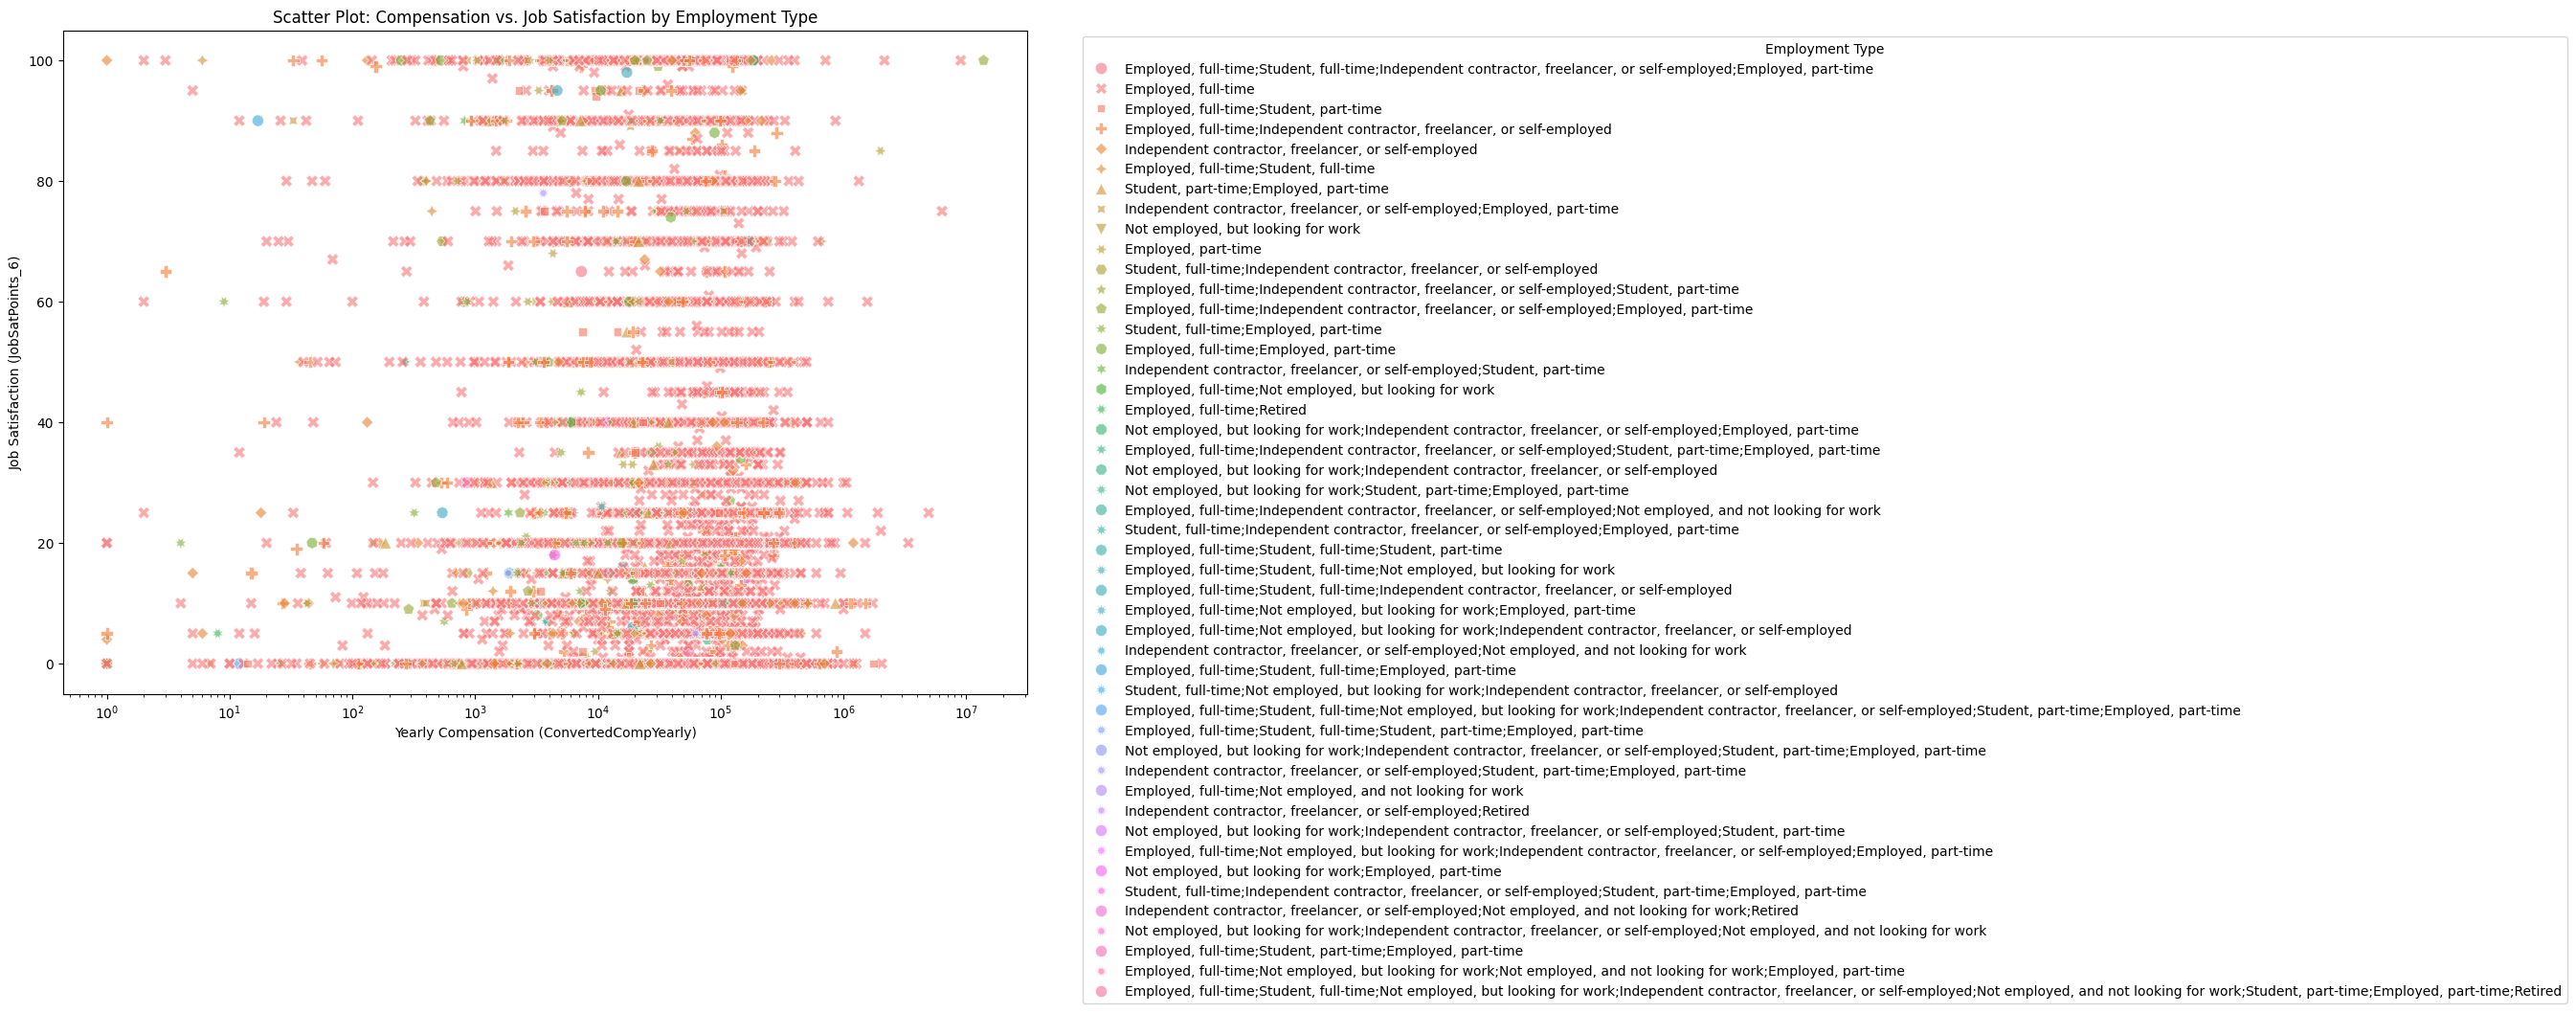

In [36]:
plt.figure(figsize=(13,9))

sns.scatterplot(
    x="ConvertedCompYearly",
    y="JobSatPoints_6",
    hue="Employment",          # color by employment type
    style="Employment",        # marker style by employment type
    data=df_clean,
    alpha=0.6,
    s=80
)

plt.xscale("log")
plt.title("Scatter Plot: Compensation vs. Job Satisfaction by Employment Type")
plt.xlabel("Yearly Compensation (ConvertedCompYearly)")
plt.ylabel("Job Satisfaction (JobSatPoints_6)")
plt.legend(title="Employment Type", bbox_to_anchor=(1.05, 1), loc='upper left')

#### 2. Scatter Plot for Work Experience vs. Age Group by Country


Compare work experience (`YearsCodePro`) across different age groups (`Age`) and countries (`Country`). Use colors to represent different countries and markers for age groups.


In [39]:
# Convert YearsCodePro to numeric
def convert_years(val):
    val = str(val).strip()
    if val.lower().startswith("less than 1"):
        return 0.5
    elif val.lower().startswith("more than 50"):
        return 51
    else:
        try:
            return float(val)
        except:
            return None

df['YearsCodePro_numeric'] = df['YearsCodePro'].apply(convert_years)

# Drop missing values
df_clean = df.dropna(subset=['Age_numeric', 'YearsCodePro_numeric', 'Country'])

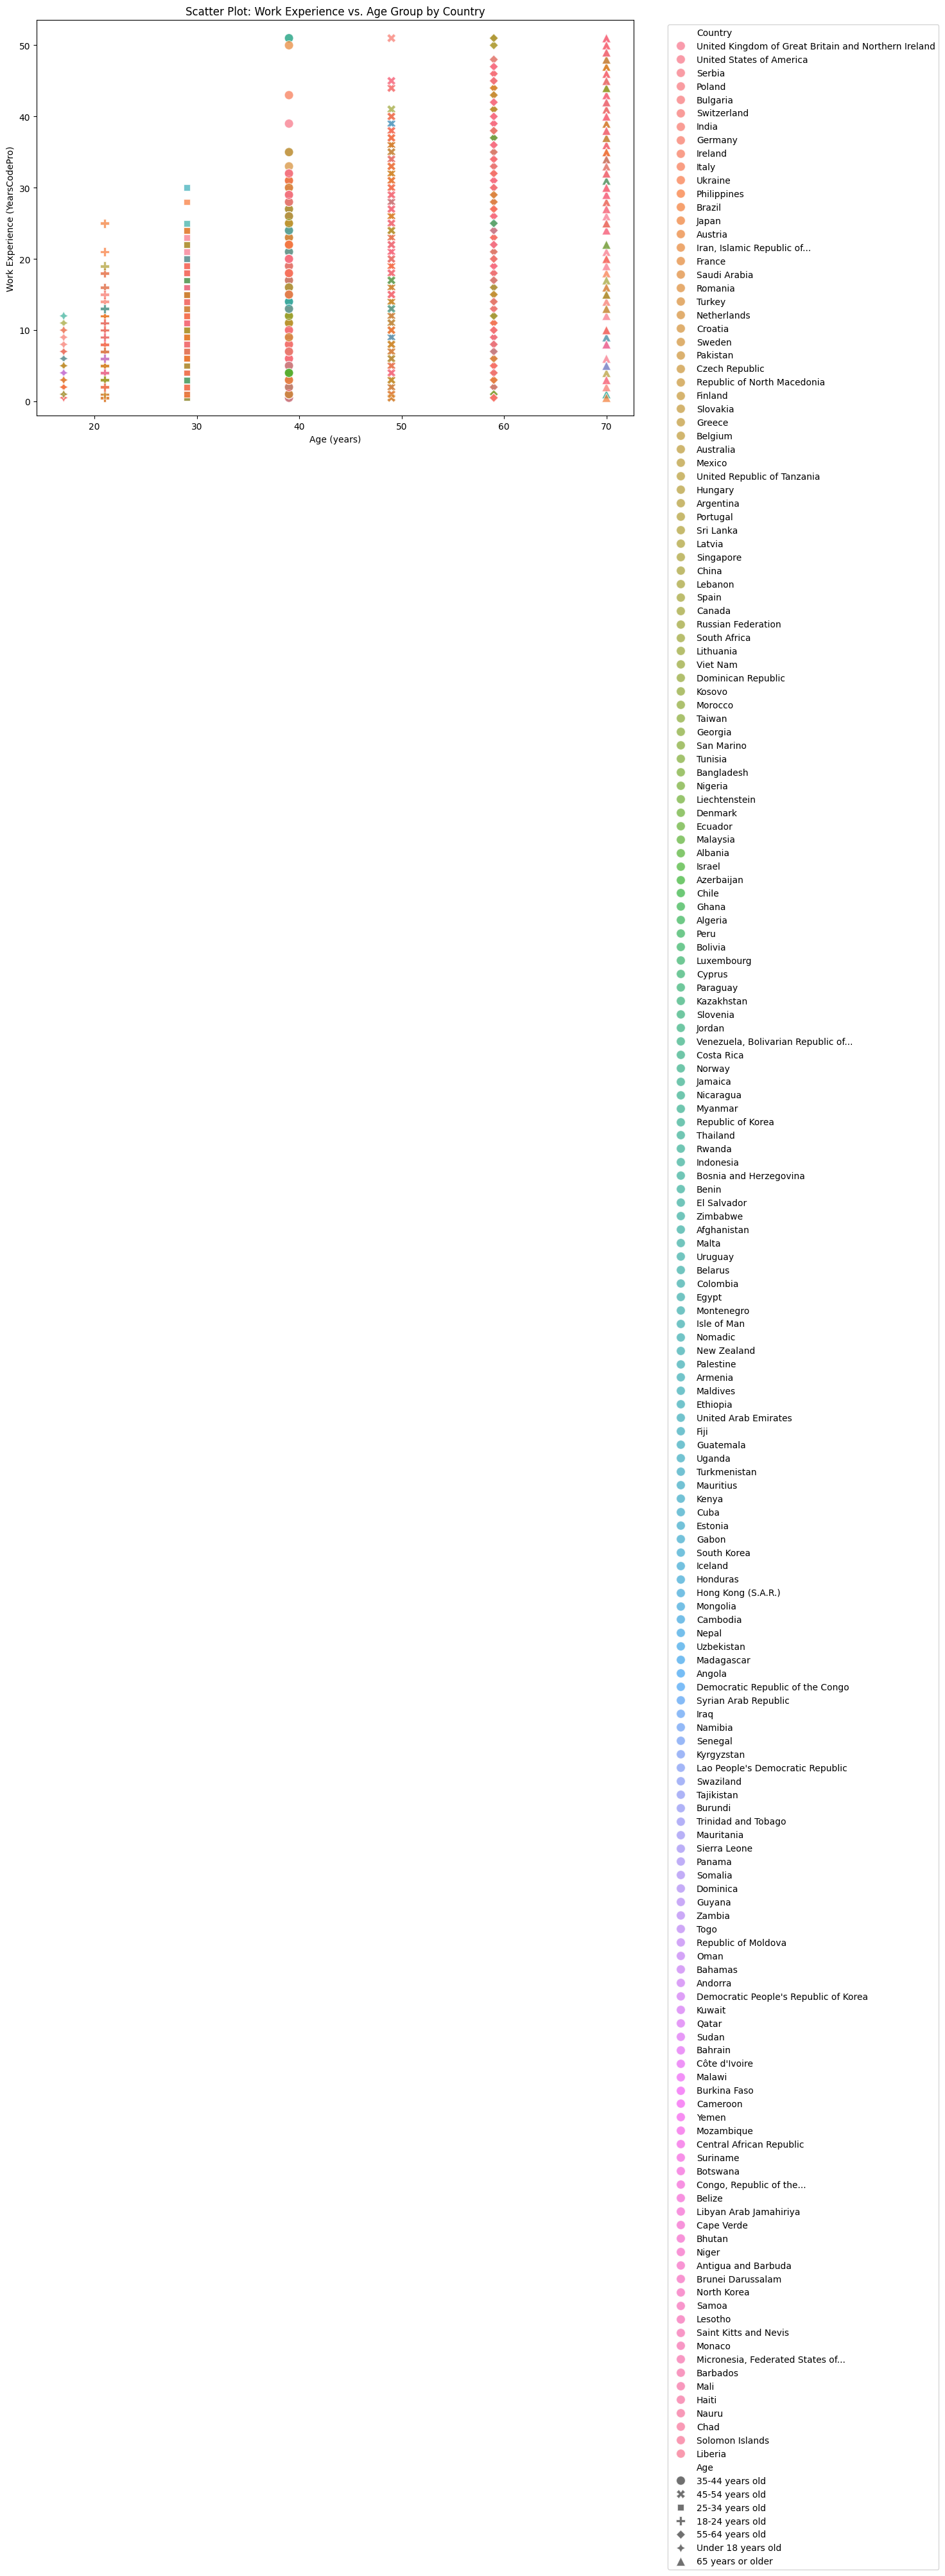

In [40]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    x="Age_numeric",
    y="YearsCodePro_numeric",
    hue="Country",          # color by country
    style="Age",            # marker style by age group
    data=df_clean,
    alpha=0.7,
    s=100
)

plt.title("Scatter Plot: Work Experience vs. Age Group by Country")
plt.xlabel("Age (years)")
plt.ylabel("Work Experience (YearsCodePro)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

### Final Step: Review


With these scatter plots, you will have analyzed data relationships across multiple dimensions, including compensation, job satisfaction, employment types, and demographics, to uncover meaningful trends in the developer community.


### Summary


After completing this lab, you will be able to:
- Analyze how numerical variables relate across specific groups, such as employment types and countries.
- Use scatter plots effectively to represent multiple variables with color, size, and markers.
- Gain insights into compensation, satisfaction, and demographic trends using advanced scatter plot techniques.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
